In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import shutil
import random
path_data=r"C:\Users\DT1\Desktop\proj-python\Images_Vision\Sign-Language-Digits-Dataset-master"
os.chdir(path_data)

In [2]:
print(os.getcwd())

C:\Users\DT1\Desktop\proj-python\Images_Vision\Sign-Language-Digits-Dataset-master


# Observe Difference between os and path

In [ ]:
# import os

# for folder in os.listdir("train"):
#     path = os.path.join("train", folder)

In [ ]:
# from pathlib import Path

# train_dir = Path("train")

# for folder in train_dir.iterdir():
#     print(folder)

| Purpose           | `os` / `os.path`   | `shutil`            |
| ----------------- | ------------------ | ------------------- |
| Current directory | `os.getcwd()`      | —                   |
| List directory    | `os.listdir()`     | —                   |
| Check existence   | `os.path.exists()` | —                   |
| Create directory  | `os.makedirs()`    | —                   |
| Join paths        | `os.path.join()`   | —                   |
| Check file        | `os.path.isfile()` | —                   |
| Copy file         | —                  | `shutil.copy()`     |
| Move file         | —                  | `shutil.move()`     |
| Delete directory  | —                  | `shutil.rmtree()`   |
| Copy directory    | —                  | `shutil.copytree()` |


# Extract Dataset

In [14]:
data_folder="Dataset"
if os.path.isdir('train/0') is False:
        os.makedirs('train', exist_ok=True)
        os.makedirs('test', exist_ok=True)
        os.makedirs('valid', exist_ok=True)
        for i in range(10):
            shutil.copytree(f'{data_folder}/{i}', f'train/{i}')
            os.makedirs(f'valid/{i}')
            os.makedirs(f'test/{i}')
            valid_samples = random.sample(os.listdir(f'train/{i}'), 30)
            for j in valid_samples:
                shutil.move(f'train/{i}/{j}', f'valid/{i}')
            test_samples = random.sample(os.listdir(f'train/{i}'), 5)
            for k in test_samples:
                shutil.move(f'train/{i}/{k}', f'test/{i}')

#

In [ ]:
train_path = 'train'
valid_path = 'valid'
test_path = 'test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 10
EPOCHS = 20


train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet.preprocess_input
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet.preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet.preprocess_input
)


# ============================================================
# 5. LOAD TRAIN DATA
# ============================================================

train_batches = train_datagen.flow_from_directory(
    directory=train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)


# ============================================================
# 6. LOAD VALIDATION DATA
# ============================================================

valid_batches = valid_datagen.flow_from_directory(
    directory=valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)


# ============================================================
# 7. LOAD TEST DATA
# ============================================================

test_batches = test_datagen.flow_from_directory(
    directory=test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


# ============================================================
# 8. INFORMATION ABOUT DATASET
# ============================================================

print("\nClasses:")
print(sorted(set(train_batches.class_indices)))
print("\nNumber of classes:", train_batches.num_classes)

print("\nTraining images:", train_batches.samples)
print("Validation images:", valid_batches.samples)
print("Test images:", test_batches.samples)




Found 1712 images belonging to 10 classes.
Found 300 images belonging to 10 classes.
Found 50 images belonging to 10 classes.

Classes:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Number of classes: 10

Training images: 1712
Validation images: 300
Test images: 50


In [ ]:

# train_ds = tf.keras.utils.image_dataset_from_directory(
#     "train",
#     image_size=(224, 224),
#     batch_size=32,
#     label_mode="int"
# )

# val_ds = tf.keras.utils.image_dataset_from_directory(
#     "valid",
#     image_size=(224, 224),
#     batch_size=32,
#     label_mode="int"
# )

# test_ds = tf.keras.utils.image_dataset_from_directory(
#     "test",
#     image_size=(224, 224),
#     batch_size=32,
#     label_mode="int",
#     shuffle=False
# )
# class_names = train_ds.class_names
# print(class_names)

Found 1712 files belonging to 10 classes.
Found 300 files belonging to 10 classes.
Found 50 files belonging to 10 classes.
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [15]:

class_names = list(train_batches.class_indices.keys())

print("\nClass names:")
print(class_names)


# ============================================================
# 10. LOAD MOBILENET
# ============================================================

base_model = MobileNet(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


# ============================================================
# 11. FREEZE MOBILENET
# ============================================================

base_model.trainable = False


# ============================================================
# 12. BUILD CUSTOM CLASSIFICATION HEAD
# # ============================================================
inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.applications.mobilenet.preprocess_input(inputs)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    train_batches.num_classes,
    activation="softmax"
)(x)



# model = tf.keras.Sequential([
#     base_model,
#     tf.keras.layers.GlobalAveragePooling2D(),
#     tf.keras.layers.Dropout(0.2),
#     tf.keras.layers.Dense(train_batches.num_classes, activation="softmax")
# ])
# ============================================================
# 13. CREATE FINAL MODEL
# ============================================================

model = Model(
    inputs=inputs,
    outputs=outputs
)


# ============================================================
# 14. MODEL SUMMARY
# ============================================================

model.summary()



Class names:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 tf.math.truediv (TFOpLambd  (None, 224, 224, 3)       0         
 a)                                                              
                                                                 
 tf.math.subtract (TFOpLamb  (None, 224, 224, 3)       0         
 da)                                                             
                                                                 
 mobilenet_1.00_224 (Functi  (None, 7, 7, 1024)        3228864   
 onal)                                                           
                                                                 
 global_average_pooling2d_1  (None, 1024)              0      

In [5]:
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)

0 input_1 False
1 conv1 False
2 conv1_bn False
3 conv1_relu False
4 conv_dw_1 False
5 conv_dw_1_bn False
6 conv_dw_1_relu False
7 conv_pw_1 False
8 conv_pw_1_bn False
9 conv_pw_1_relu False
10 conv_pad_2 False
11 conv_dw_2 False
12 conv_dw_2_bn False
13 conv_dw_2_relu False
14 conv_pw_2 False
15 conv_pw_2_bn False
16 conv_pw_2_relu False
17 conv_dw_3 False
18 conv_dw_3_bn False
19 conv_dw_3_relu False
20 conv_pw_3 False
21 conv_pw_3_bn False
22 conv_pw_3_relu False
23 conv_pad_4 False
24 conv_dw_4 False
25 conv_dw_4_bn False
26 conv_dw_4_relu False
27 conv_pw_4 False
28 conv_pw_4_bn False
29 conv_pw_4_relu False
30 conv_dw_5 False
31 conv_dw_5_bn False
32 conv_dw_5_relu False
33 conv_pw_5 False
34 conv_pw_5_bn False
35 conv_pw_5_relu False
36 conv_pad_6 False
37 conv_dw_6 False
38 conv_dw_6_bn False
39 conv_dw_6_relu False
40 conv_pw_6 False
41 conv_pw_6_bn False
42 conv_pw_6_relu False
43 conv_dw_7 False
44 conv_dw_7_bn False
45 conv_dw_7_relu False
46 conv_pw_7 False
47 conv_pw_7_bn 

In [ ]:
# base_model.trainable = True

# for layer in base_model.layers[:-30]:
#     layer.trainable = False

In [17]:

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 16. CALLBACKS
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


checkpoint = ModelCheckpoint(
    "best_mobilenet_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)


# ============================================================
# 17. TRAIN MODEL
# ============================================================

history = model.fit(
    train_batches,
    validation_data=valid_batches,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        checkpoint
    ]
)



Epoch 1/20


172/172 [==============================] - ETA: 0s - loss: 2.1643 - accuracy: 0.2669
Epoch 1: val_accuracy improved from -inf to 0.63000, saving model to best_mobilenet_model.keras
172/172 [==============================] - 58s 313ms/step - loss: 2.1643 - accuracy: 0.2669 - val_loss: 1.5386 - val_accuracy: 0.6300
Epoch 2/20
172/172 [==============================] - ETA: 0s - loss: 1.5128 - accuracy: 0.4959
Epoch 2: val_accuracy improved from 0.63000 to 0.77333, saving model to best_mobilenet_model.keras
172/172 [==============================] - 58s 339ms/step - loss: 1.5128 - accuracy: 0.4959 - val_loss: 1.1502 - val_accuracy: 0.7733
Epoch 3/20
172/172 [==============================] - ETA: 0s - loss: 1.1910 - accuracy: 0.6343
Epoch 3: val_accuracy improved from 0.77333 to 0.83333, saving model to best_mobilenet_model.keras
172/172 [==============================] - 57s 328ms/step - loss: 1.1910 - accuracy: 0.6343 - val_loss: 0.8913 - val_accuracy: 0.8333
Epoch 4/20
172

5/5 [==============================] - 1s 246ms/step - loss: 0.1131 - accuracy: 0.9600

Test Loss: 0.11307927966117859
Test Accuracy: 0.9599999785423279


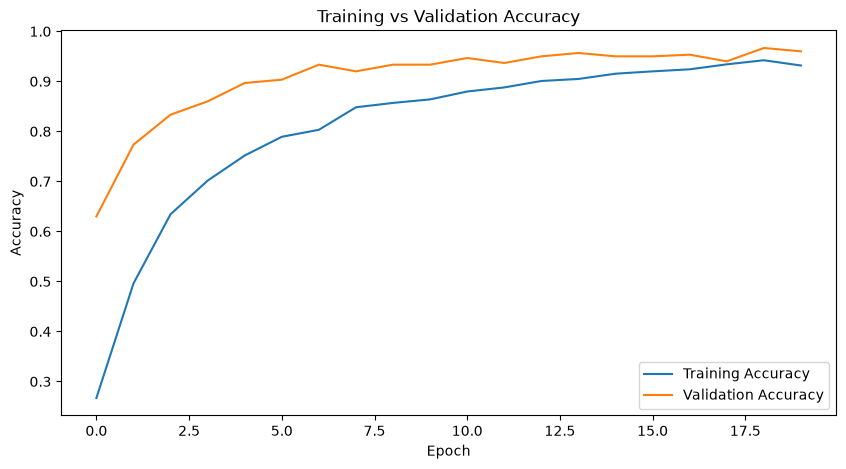

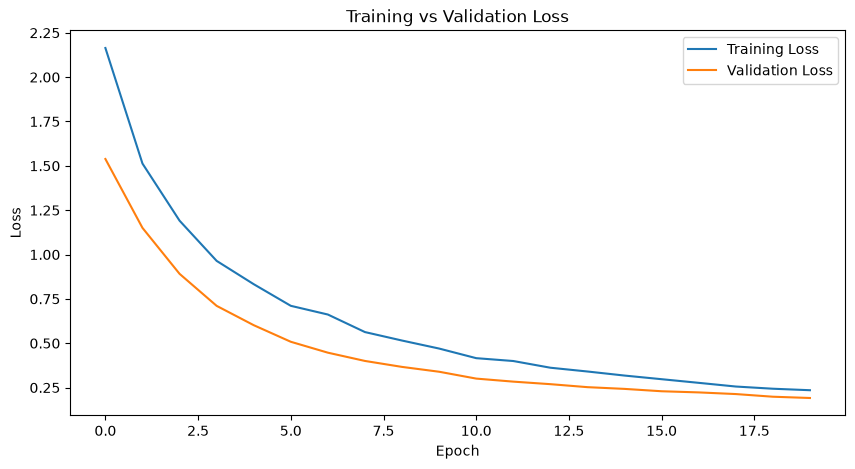

In [18]:

# ============================================================
# 18. EVALUATE ON TEST DATA
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_batches
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


# ============================================================
# 19. PLOT TRAINING / VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()


# ============================================================
# 20. PLOT TRAINING / VALIDATION LOSS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()



5/5 [==============================] - 3s 310ms/step

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5
           2       1.00      0.80      0.89         5
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       0.83      1.00      0.91         5
           7       0.83      1.00      0.91         5
           8       1.00      0.80      0.89         5
           9       1.00      1.00      1.00         5

    accuracy                           0.96        50
   macro avg       0.97      0.96      0.96        50
weighted avg       0.97      0.96      0.96        50



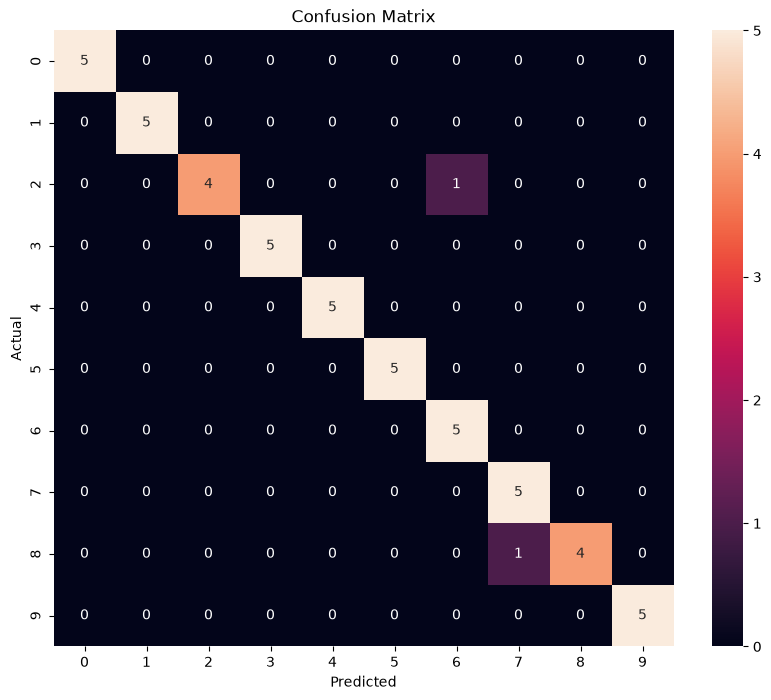


Model saved successfully.

Model loaded successfully.


In [19]:

# ============================================================
# 21. PREDICTIONS
# ============================================================

test_batches.reset()

predictions = model.predict(
    test_batches
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = test_batches.classes


# ============================================================
# 22. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)


# ============================================================
# 23. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ============================================================
# 24. SAVE FINAL MODEL
# ============================================================

model.save(
    "mobilenet_classifier.keras"
)

print("\nModel saved successfully.")


# ============================================================
# 25. LOAD SAVED MODEL
# ============================================================

loaded_model = tf.keras.models.load_model(
    "mobilenet_classifier.keras"
)

print("\nModel loaded successfully.")



In [20]:

# ============================================================
# 26. PREDICT ONE IMAGE
# ============================================================

from tensorflow.keras.utils import load_img, img_to_array


def predict_image(image_path):

    # Load image
    image = load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert image to NumPy array
    image_array = img_to_array(image)

    # Add batch dimension
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # MobileNet preprocessing
    image_array = tf.keras.applications.mobilenet.preprocess_input(
        image_array
    )

    # Prediction
    prediction = model.predict(
        image_array,
        verbose=0
    )

    # Get predicted class
    predicted_index = np.argmax(
        prediction[0]
    )

    predicted_class = class_names[predicted_index]

    confidence = prediction[0][predicted_index]

    print("\nPredicted class:", predicted_class)
    print("Confidence:", f"{confidence * 100:.2f}%")

    return predicted_class, confidence


# ============================================================
# 27. TEST ONE IMAGE
# ============================================================

# Change this to your image
image_path = "Examples/example_1.jpg"

predict_image(image_path)


Predicted class: 1
Confidence: 98.26%


('1', 0.98256487)

In [18]:
import cv2
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("best_mobilenet_model.keras")

cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    resized = cv2.resize(
        rgb,
        (224, 224)
    )

    input_image = np.expand_dims(
        resized.astype(np.float32),
        axis=0
    )

    input_image = preprocess_input(
        input_image
    )

    prediction = model.predict(
        input_image,
        verbose=0
    )[0]

    index = np.argmax(prediction)

    label = class_names[index]

    confidence = prediction[index]

    text = f"{label}: {confidence:.2f}"

    cv2.putText(
        frame,
        text,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.imshow(
        "MobileNet",
        frame
    )

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
cv2.destroyAllWindows()